# Age-attribute control for the generalisation tests

The leading configuration is conditioned, through FiLM, on three radar
attributes per view, the first of which is acquisition age relative to the
LiDAR survey, scaled by 30. In training that value lay in $[-0.97, +0.70]$.
The unseen-date test (`08`) supplied 11.4--11.8 and the Cambridge Bay test
(`13`) supplied 13.4--13.6: both generalisation tests asked the network to
extrapolate a conditioning variable to roughly twelve times its training
range.

This notebook is the control that `08` and `13` lacked. It re-runs
inference with the **same checkpoint, same patches, same imagery**, varying
only the age attribute:

| setting  | age attribute                          | what it tests                       |
|----------|----------------------------------------|-------------------------------------|
| `real`   | as computed (≈ 11.6 / 13.5)             | reproduces `08` / `13`              |
| `clamp`  | clipped to the training max (+0.70)     | in-range value, everything else same|
| `zero`   | 0.0 (orbit direction / rel. orbit kept) | attribute removed entirely          |

If `clamp`/`zero` stay near ZNCC 0, the collapse is in the imagery
(saturation, dB offset) and the age confound is dismissed. If they recover
toward the in-region 0.26, the collapse was the attribute, not the radar.

Part A (unseen dates, 25 patches x 3 settings) takes minutes. Part B
(Cambridge Bay, `N_CB` patches x 2 settings) is optional and gated by
`RUN_CB`.

In [1]:
import os, sys, json, random, datetime as dt
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), 'CUDA is required.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4090


In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = WORKING_REPO / 'tessa_baseline'
CHECKPOINT_NAME = 's1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth'   # 09's checkpoint, as in 08 and 13
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'

# Tuktoyaktuk (Part A) -- identical to 08
TUK_S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
TUK_LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
TUK_SURVEY_DATE = dt.date(2024, 4, 16)
UNSEEN_DIR = WORKING_REPO / 'raw_data' / 'tuk_unseen_date_test'      # t0/t1/t2.tif written by 08
UNSEEN_DATES = [dt.date(2025, 3, 25), dt.date(2025, 3, 27), dt.date(2025, 4, 6)]  # printed by 08, in t0..t2 order

# Cambridge Bay (Part B) -- identical to 13
RUN_CB = True
N_CB = 50                       # 13 used 400; 50 x 2 settings ~ 30 min of DDIM. Raise if time allows.
CB_S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_cambridge_pcrtc'
CB_LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_cambridge_extracted' / 'lidar_patches_cambridge'
CB_SURVEY_DATE = dt.date(2024, 4, 18)

CONTEXT_K = 3
TARGET_HW = (256, 256)
TIMESTEPS = 1000
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'
BLOCK_SIZE_M = 1024.0
BUFFER_M = 150.0
N_TEST_PATCHES = 25              # 08's sample size and seed (SEED + 2) -> same 25 patches

AGE_TRAIN_MIN, AGE_TRAIN_MAX = -29 / 30.0, 21 / 30.0   # 18 Mar .. 7 May 2024 relative to 16 Apr
SETTINGS = ['real', 'clamp', 'zero']

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddim
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

model = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128,
                        embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
scheduler = LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE)
checkpoint = torch.load(CHECKPOINT_DIR / CHECKPOINT_NAME, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict']); model.eval()
sampler = p_sample_loop_ddim
print('Loaded', CHECKPOINT_NAME, '| epoch', checkpoint.get('epoch'), '| val_loss', checkpoint.get('val_loss'))

Loaded s1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth | epoch 93 | val_loss 0.013706092446227558


## Shared helpers

In [4]:
def apply_setting(attrs, setting):
    # attrs: [K*8] flat; age is slot 0 of each 8-vector
    a = attrs.clone().view(CONTEXT_K, 8)
    if setting == 'clamp':
        a[:, 0] = a[:, 0].clamp(AGE_TRAIN_MIN, AGE_TRAIN_MAX)
    elif setting == 'zero':
        a[:, 0] = 0.0
    elif setting != 'real':
        raise ValueError(setting)
    return a.flatten()

def load_target(lidar_dir, pid):
    with rasterio.open(lidar_dir / f'lidar_patch_{pid}.tif') as src:
        raw = src.read().astype(np.float32)
    target = raw[0]
    mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
    target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
    patch_mean = float(target[mask].sum() / max(1, mask.sum()))
    return (target - patch_mean) * mask, mask, patch_mean

def sar_to_condition(raw_views):
    # raw_views: [K, 2, h, w] linear gamma0 -> dB -> bilinear to TARGET_HW -> repeat to 4 ch, as in training
    views = []
    for k in range(CONTEXT_K):
        sar = np.nan_to_num(raw_views[k], nan=0.0, posinf=0.0, neginf=0.0)
        sar = 10.0 * np.log10(np.maximum(sar, 1e-12))
        t = F.interpolate(torch.from_numpy(sar).unsqueeze(0), size=TARGET_HW, mode='bilinear', align_corners=False).squeeze(0)
        views.append(t.repeat(2, 1, 1))
    return torch.cat(views, dim=0)

@torch.no_grad()
def evaluate(pid, condition, attrs, target_demeaned, mask, patch_mean):
    condition = condition.unsqueeze(0).to(DEVICE)
    attrs = attrs.unsqueeze(0).to(DEVICE)
    target_t = torch.from_numpy(target_demeaned).unsqueeze(0).unsqueeze(0).to(DEVICE)
    mask_t = torch.from_numpy(mask).unsqueeze(0).to(DEVICE).bool()
    prediction = sampler(model, scheduler, target_t.shape, condition, attrs, DEVICE)
    mean_t = torch.tensor(patch_mean, device=DEVICE).view(1, 1, 1, 1)
    gt_i, pred_i, mask_i = (target_t + mean_t)[0], (prediction + mean_t)[0], mask_t[0]
    gt_valid = gt_i.squeeze()[mask_i].cpu().numpy(); pred_valid = pred_i.squeeze()[mask_i].cpu().numpy()
    return {
        'patch_id': pid,
        'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
        'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
        'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
        'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
        'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
        'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
        'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
        'gt_std_val': float(gt_valid.std()), 'pred_std_val': float(pred_valid.std()),
    }

def summarise(rows):
    return {k: float(np.nanmean([r[k] for r in rows])) for k in rows[0] if k != 'patch_id'}

def run_settings(items, settings, tag):
    # items: list of (pid, condition, real_attrs, target, mask, patch_mean)
    results = {}
    for setting in settings:
        seed_everything(SEED)          # same noise draw per setting, so the only difference is the attribute
        rows = []
        for i, (pid, cond, attrs, tgt, msk, pm) in enumerate(items):
            rows.append(evaluate(pid, cond, apply_setting(attrs, setting), tgt, msk, pm))
            if (i + 1) % 10 == 0: print(f'  [{tag}/{setting}] {i + 1}/{len(items)}')
        results[setting] = {'rows': rows, 'mean': summarise(rows)}
        print(f'{tag} / {setting:<5}  ZNCC {results[setting]["mean"]["zncc"]:+.4f}   '
              f'pred_std {results[setting]["mean"]["pred_std_val"]:.4f}   sigma_err {results[setting]["mean"]["sigma_error_pct"]:.1f}%')
    return results

## Part A -- unseen dates (Tuktoyaktuk)

Reconstructs `09`'s validation split exactly as `08` did, draws the same 25
patches (`random.Random(SEED + 2)`), and reads the three 2025 scenes `08`
saved to `raw_data/tuk_unseen_date_test/`. Orbit direction and relative
orbit are re-derived from the scene filenames written by `08` if present;
otherwise they are taken from the STAC query below.

In [5]:
# --- split, as in 08/09 ---
lidar_ids = {p.stem.split('_')[-1] for p in TUK_LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in TUK_S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)

def centroid(pid):
    with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as src: b = src.bounds
    return ((b.left + b.right) / 2, (b.bottom + b.top) / 2)

blocks, dropped = {}, []
for pid in paired_ids:
    cx, cy = centroid(pid)
    bx, by = int(cx // BLOCK_SIZE_M), int(cy // BLOCK_SIZE_M)
    d = min(cx - bx * BLOCK_SIZE_M, (bx + 1) * BLOCK_SIZE_M - cx, cy - by * BLOCK_SIZE_M, (by + 1) * BLOCK_SIZE_M - cy)
    (dropped if d < BUFFER_M else blocks.setdefault((bx, by), [])).append(pid)
block_ids = list(blocks); random.Random(SEED).shuffle(block_ids)
target_val = int(len(paired_ids) * VAL_FRACTION)
val_ids, n = [], 0
for bid in block_ids:
    if n < target_val: val_ids.extend(blocks[bid]); n += len(blocks[bid])
print(f'val={len(val_ids)} (expect 255), dropped as buffer={len(dropped)}')
assert len(val_ids) == 255, 'split does not match 09 -- check BLOCK_SIZE_M/BUFFER_M/SEED'

test_patch_ids = random.Random(SEED + 2).sample(val_ids, min(N_TEST_PATCHES, len(val_ids)))
print('Same 25 patches as 08:', test_patch_ids[:5], '...')

val=255 (expect 255), dropped as buffer=887
Same 25 patches as 08: ['13444', '13127', '13172', '12231', '12654'] ...


In [6]:
# --- unseen-date scenes and their attributes ---
merged_paths = [UNSEEN_DIR / f't{i}.tif' for i in range(CONTEXT_K)]
assert all(p.exists() for p in merged_paths), f'08 outputs missing in {UNSEEN_DIR}; re-run 08 step 2 first'

# Orbit metadata: query STAC for the same window and match on date (cheap; no download).
import pystac_client, planetary_computer
from dotenv import load_dotenv
load_dotenv()
if os.environ.get('PC_SDK_SUBSCRIPTION_KEY'):
    planetary_computer.settings.set_subscription_key(os.environ['PC_SDK_SUBSCRIPTION_KEY'])
with rasterio.open(merged_paths[0]) as src:
    aoi_ll = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
cat = pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1', modifier=planetary_computer.sign_inplace)
start, end = UNSEEN_DATES[0] - dt.timedelta(days=1), UNSEEN_DATES[-1] + dt.timedelta(days=1)
items = {it.datetime.date(): it for it in cat.search(collections=['sentinel-1-rtc'], bbox=aoi_ll,
                                                      datetime=f'{start.isoformat()}/{end.isoformat()}').items()}
vecs = []
for d in UNSEEN_DATES:
    it = items.get(d)
    orbit_dir = 1.0 if (it and it.properties.get('sat:orbit_state') == 'ascending') else 0.0
    rel_orbit = ((it.properties.get('sat:relative_orbit') if it else 0) or 0) / 175.0
    vecs.append([(d - TUK_SURVEY_DATE).days / 30.0, orbit_dir, rel_orbit, 0, 0, 0, 0, 0])
    print(d, '| age_norm', f'{vecs[-1][0]:.2f}', '| orbit', 'asc' if orbit_dir else 'desc', '| rel_orbit', it.properties.get('sat:relative_orbit') if it else None)
unseen_attrs = torch.tensor(vecs, dtype=torch.float32).flatten()
print('training age range', (AGE_TRAIN_MIN, AGE_TRAIN_MAX), '| test age', [round(v[0], 2) for v in vecs])

2025-03-25 | age_norm 11.43 | orbit asc | rel_orbit 108
2025-03-27 | age_norm 11.50 | orbit asc | rel_orbit 137
2025-04-06 | age_norm 11.83 | orbit asc | rel_orbit 108
training age range (-0.9666666666666667, 0.7) | test age [11.43, 11.5, 11.83]


In [7]:
def extract_unseen(pid):
    with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as l:
        lb, lcrs, h, w = l.bounds, l.crs, l.height, l.width
    views = []
    for mp in merged_paths:
        with rasterio.open(mp) as src:
            win = from_bounds(*transform_bounds(lcrs, src.crs, *lb, densify_pts=21), transform=src.transform)
            views.append(src.read(window=win, out_shape=(2, h, w)))
    return np.stack(views)

items_A = []
for pid in test_patch_ids:
    tgt, msk, pm = load_target(TUK_LIDAR_DIR, pid)
    items_A.append((pid, sar_to_condition(extract_unseen(pid)), unseen_attrs, tgt, msk, pm))
print(f'Prepared {len(items_A)} unseen-date items')

results_A = run_settings(items_A, SETTINGS, 'unseen-date')

Prepared 25 unseen-date items
  [unseen-date/real] 10/25
  [unseen-date/real] 20/25
unseen-date / real   ZNCC -0.0094   pred_std 0.0918   sigma_err 48.8%
  [unseen-date/clamp] 10/25
  [unseen-date/clamp] 20/25
unseen-date / clamp  ZNCC -0.0106   pred_std 0.0892   sigma_err 49.7%
  [unseen-date/zero] 10/25
  [unseen-date/zero] 20/25
unseen-date / zero   ZNCC -0.0111   pred_std 0.0881   sigma_err 50.1%


In [8]:
# in-region reference for the same 25 patches (training-date imagery, real attrs) -- so the comparison is like-for-like
def load_training_views(pid):
    s1_path = TUK_S1_DIR / f's1_patch_{pid}'
    times = sorted(s1_path.glob('t*.tif'))[:CONTEXT_K]
    raw = np.stack([rasterio.open(t).read()[:2].astype(np.float32) for t in times])
    attrs_list = json.load(open(s1_path / 'attrs.json'))
    vecs = []
    for t in times:
        a = attrs_list[int(t.stem[1:])]
        age = (dt.date.fromisoformat(a['acquisition_date']) - TUK_SURVEY_DATE).days / 30.0 if a.get('acquisition_date') else 0.0
        vecs.append([age, 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0, (a.get('relative_orbit_number') or 0) / 175.0, 0, 0, 0, 0, 0])
    return raw, torch.tensor(vecs, dtype=torch.float32).flatten()

items_ref = []
for pid in test_patch_ids:
    raw, attrs = load_training_views(pid)
    tgt, msk, pm = load_target(TUK_LIDAR_DIR, pid)
    items_ref.append((pid, sar_to_condition(raw), attrs, tgt, msk, pm))
results_ref = run_settings(items_ref, ['real'], 'in-region (same 25)')

  [in-region (same 25)/real] 10/25
  [in-region (same 25)/real] 20/25
in-region (same 25) / real   ZNCC +0.2592   pred_std 0.1421   sigma_err 23.4%


## Part B -- Cambridge Bay (optional)

Same checkpoint, first `N_CB` of `13`'s 400-patch subsample
(`random.Random(42)` over the sorted paired ids), two settings. Age relative
to the **Cambridge Bay** survey date, as in `13`.

In [9]:
results_B = None
if RUN_CB:
    cb_lidar = {p.stem.split('_')[-1] for p in CB_LIDAR_DIR.glob('lidar_patch_*.tif')}
    cb_s1 = {p.name.split('_')[-1] for p in CB_S1_DIR.glob('s1_patch_*') if p.is_dir()}
    cb_all = sorted(cb_lidar & cb_s1)
    cb_400 = random.Random(42).sample(cb_all, min(400, len(cb_all)))     # 13's subsample
    cb_ids = cb_400[:N_CB]
    print(f'Cambridge Bay: {len(cb_all)} paired (expect 2101); using first {len(cb_ids)} of 13\'s 400')

    def load_cb(pid):
        s1_path = CB_S1_DIR / f's1_patch_{pid}'
        times = sorted(s1_path.glob('t*.tif'))[:CONTEXT_K]
        raw = np.stack([rasterio.open(t).read()[:2].astype(np.float32) for t in times])
        attrs_list = json.load(open(s1_path / 'attrs.json'))
        vecs = []
        for t in times:
            a = attrs_list[int(t.stem[1:])]
            age = (dt.date.fromisoformat(a['acquisition_date']) - CB_SURVEY_DATE).days / 30.0 if a.get('acquisition_date') else 0.0
            vecs.append([age, 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0, (a.get('relative_orbit_number') or 0) / 175.0, 0, 0, 0, 0, 0])
        return raw, torch.tensor(vecs, dtype=torch.float32).flatten()

    items_B = []
    for pid in cb_ids:
        raw, attrs = load_cb(pid)
        tgt, msk, pm = load_target(CB_LIDAR_DIR, pid)
        items_B.append((pid, sar_to_condition(raw), attrs, tgt, msk, pm))
    print('CB age_norm values:', sorted({round(float(v), 2) for it in items_B[:1] for v in it[2].view(CONTEXT_K, 8)[:, 0]}))
    results_B = run_settings(items_B, ['real', 'clamp'], 'cambridge-bay')

Cambridge Bay: 2101 paired (expect 2101); using first 50 of 13's 400
CB age_norm values: [13.4, 13.47, 13.63]
  [cambridge-bay/real] 10/50
  [cambridge-bay/real] 20/50
  [cambridge-bay/real] 30/50
  [cambridge-bay/real] 40/50
  [cambridge-bay/real] 50/50
cambridge-bay / real   ZNCC +0.0089   pred_std 0.3104   sigma_err 470.7%
  [cambridge-bay/clamp] 10/50
  [cambridge-bay/clamp] 20/50
  [cambridge-bay/clamp] 30/50
  [cambridge-bay/clamp] 40/50
  [cambridge-bay/clamp] 50/50
cambridge-bay / clamp  ZNCC +0.0093   pred_std 0.3112   sigma_err 472.1%


## Summary

In [10]:
def row(label, m):
    return f"{label:<34} {m['zncc']:+.4f}   {m['rmse_m']:.4f}   {m['sigma_error_pct']:7.1f}   {m['jsd']:.4f}   {m['psd_rmse']:.4f}   {m['pred_std_val']:.4f} / {m['gt_std_val']:.4f}"

print(f"{'run':<34} {'ZNCC':>7}   {'RMSE':>6}   {'sig%':>7}   {'JSD':>6}   {'PSD':>6}   pred/gt std")
print('-' * 100)
print(row('in-region, same 25, real attrs', results_ref['real']['mean']))
for s in SETTINGS: print(row(f'unseen dates, age={s}', results_A[s]['mean']))
if results_B:
    for s in ['real', 'clamp']: print(row(f'Cambridge Bay ({N_CB}), age={s}', results_B[s]['mean']))

# Threshold from Chapter 4: single run vs 3-run mean resolvable at |delta| >= 0.130 (t(2)=4.303 x 0.0303).
# Here every setting is evaluated on the SAME patches with the SAME noise seed, so the comparison
# real -> clamp/zero is paired and far tighter than that; report the paired mean difference and its s.e.
def paired(rA, rB):
    a = np.array([r['zncc'] for r in rA['rows']]); b = np.array([r['zncc'] for r in rB['rows']])
    d = b - a
    return d.mean(), d.std(ddof=1) / np.sqrt(len(d))
print()
for s in ['clamp', 'zero']:
    m, se = paired(results_A['real'], results_A[s])
    print(f'unseen dates: ZNCC({s}) - ZNCC(real) = {m:+.4f} +/- {se:.4f} (s.e., n={len(items_A)})')
if results_B:
    m, se = paired(results_B['real'], results_B['clamp'])
    print(f'Cambridge Bay: ZNCC(clamp) - ZNCC(real) = {m:+.4f} +/- {se:.4f} (s.e., n={N_CB})')

out = {
    'checkpoint': CHECKPOINT_NAME,
    'age_train_range': [AGE_TRAIN_MIN, AGE_TRAIN_MAX],
    'unseen_dates': [d.isoformat() for d in UNSEEN_DATES],
    'unseen_age_norm': [float(v) for v in unseen_attrs.view(CONTEXT_K, 8)[:, 0]],
    'n_unseen_patches': len(items_A), 'patch_ids': test_patch_ids,
    'in_region_same_patches': results_ref['real']['mean'],
    'unseen_dates_by_setting': {s: results_A[s]['mean'] for s in SETTINGS},
    'unseen_dates_rows': {s: results_A[s]['rows'] for s in SETTINGS},
    'cambridge_bay_by_setting': ({s: results_B[s]['mean'] for s in results_B} if results_B else None),
    'cambridge_bay_rows': ({s: results_B[s]['rows'] for s in results_B} if results_B else None),
    'n_cb_patches': N_CB if results_B else 0,
}
path = OUTPUT_DIR / 's1_pcrtc_age_attribute_control.json'
json.dump(out, open(path, 'w'), indent=2)
print('\nSaved:', path)

run                                   ZNCC     RMSE      sig%      JSD      PSD   pred/gt std
----------------------------------------------------------------------------------------------------
in-region, same 25, real attrs     +0.2592   0.1974      23.4   0.1212   1.2820   0.1421 / 0.1798
unseen dates, age=real             -0.0094   0.2072      48.8   0.2701   1.3153   0.0918 / 0.1798
unseen dates, age=clamp            -0.0106   0.2059      49.7   0.2768   1.3257   0.0892 / 0.1798
unseen dates, age=zero             -0.0111   0.2054      50.1   0.2799   1.3293   0.0881 / 0.1798
Cambridge Bay (50), age=real       +0.0089   0.3370     470.7   0.5512   1.5585   0.3104 / 0.0913
Cambridge Bay (50), age=clamp      +0.0093   0.3384     472.1   0.5522   1.5614   0.3112 / 0.0913

unseen dates: ZNCC(clamp) - ZNCC(real) = -0.0012 +/- 0.0007 (s.e., n=25)
unseen dates: ZNCC(zero) - ZNCC(real) = -0.0017 +/- 0.0010 (s.e., n=25)
Cambridge Bay: ZNCC(clamp) - ZNCC(real) = +0.0005 +/- 0.0023 (s.e., n=5

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_age_attribute_control.png


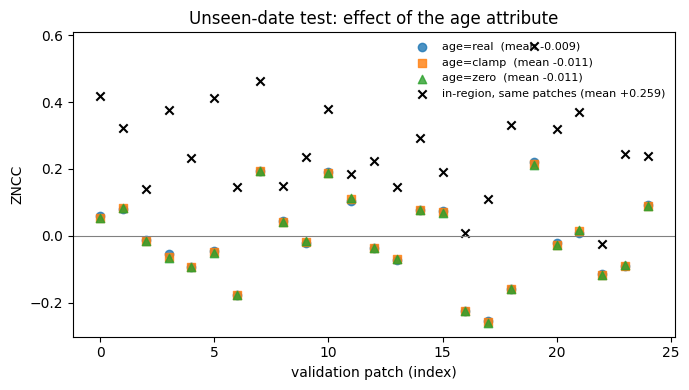

In [11]:
# One figure: ZNCC per patch, real vs clamp vs zero, unseen dates
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(items_A))
for s, mk in zip(SETTINGS, ['o', 's', '^']):
    ax.scatter(x, [r['zncc'] for r in results_A[s]['rows']], marker=mk, label=f'age={s}  (mean {results_A[s]["mean"]["zncc"]:+.3f})', alpha=0.8)
ax.scatter(x, [r['zncc'] for r in results_ref['real']['rows']], marker='x', c='k', label=f'in-region, same patches (mean {results_ref["real"]["mean"]["zncc"]:+.3f})')
ax.axhline(0, c='grey', lw=0.8)
ax.set_xlabel('validation patch (index)'); ax.set_ylabel('ZNCC'); ax.legend(fontsize=8, frameon=False)
ax.set_title('Unseen-date test: effect of the age attribute')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 's1_pcrtc_age_attribute_control.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_pcrtc_age_attribute_control.png')
plt.show()

## How to read the result

- **clamp/zero ≈ real ≈ 0** → the age extrapolation is not the cause. Cut the
  new limitation paragraph to one sentence citing this notebook; the
  saturation/dB reading in §5.2 stands on its own.
- **clamp/zero recover toward the in-region figure** → the collapse in `08`
  (and, if Part B agrees, `13`) was FiLM extrapolation, not the radar. That
  is a finding: §4.9, §5.2.1–5.2.2 and the Conclusion's "on unseen dates ...
  correlation falls to zero" all need rewriting, and the generalisation
  numbers in `tab:all_runs` should be re-reported under `clamp`.
- **partial recovery** (e.g. to ~0.1) → both factors contribute; report both
  numbers and keep the limitation paragraph.

The paired difference printed above is the statistic to quote: same patches,
same noise, one variable changed.